## Clustering (+ Atchley factors visualization)

In [1]:
import pandas as pd
df = pd.read_csv("../../data/samples_DBAASP/descriptors_positive_staphylococcus.csv")

# drop tail from index 450
# df = df.drop(df.index[450:])

In [2]:
# normalizing the data using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)
df_feat = pd.DataFrame(scaled_features, columns=df.columns)

<Axes: >

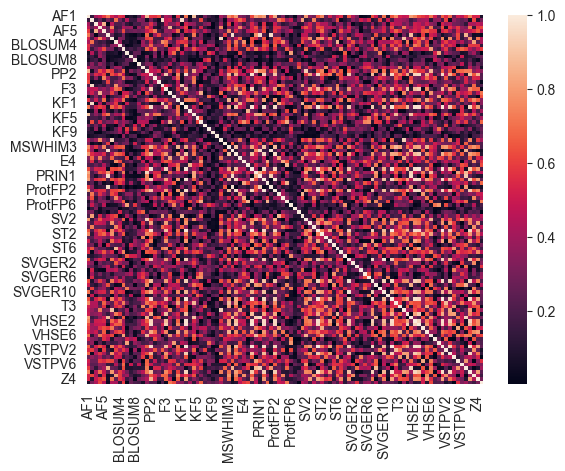

In [3]:
# variance matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_feat.corr().abs()
sns.heatmap(corr_matrix, annot=False)

In [4]:
# variance treshold - remove features with zero variance
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold()
selector.fit(df_feat)
df_feat = df_feat[df_feat.columns[selector.get_support(indices=True)]]

print(f"Features dropped: {df.columns[~selector.get_support()]}")
print(f"New shape: {df_feat.shape}")

Features dropped: Index([], dtype='object')
New shape: (721, 102)


In [5]:
# trash randomly one of the features with correlation > 0.8
corr_matrix = df_feat.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
df_feat = df_feat.drop(columns=to_drop)

print(f"Features dropped: {to_drop}")
print(f"New shape: {df_feat.shape}")


Features dropped: ['AF5', 'PP1', 'F2', 'F3', 'F4', 'KF1', 'KF2', 'KF4', 'KF6', 'MSWHIM1', 'MSWHIM3', 'E1', 'E2', 'E3', 'E5', 'PD1', 'PD2', 'PRIN1', 'PRIN2', 'PRIN3', 'ProtFP1', 'ProtFP2', 'ProtFP3', 'ProtFP4', 'ProtFP5', 'ProtFP6', 'SV1', 'SV2', 'SV3', 'SV4', 'ST1', 'ST4', 'ST6', 'SVGER1', 'SVGER7', 'SVGER10', 'T1', 'T2', 'T3', 'T4', 'T5', 'VHSE1', 'VHSE2', 'VHSE3', 'VHSE4', 'VHSE5', 'VHSE6', 'VHSE8', 'VSTPV1', 'VSTPV2', 'VSTPV3', 'VSTPV4', 'VSTPV5', 'Z1', 'Z2', 'Z3', 'Z4']
New shape: (721, 45)


In [6]:
# # trash all features with "BLOSUM" in the name
# to_drop = [col for col in df_feat.columns if "BLOSUM" in col]
# df_feat = df_feat.drop(columns=to_drop)
# 
# print(f"Features dropped: {to_drop}")
# print(f"New shape: {df_feat.shape}")

<Axes: >

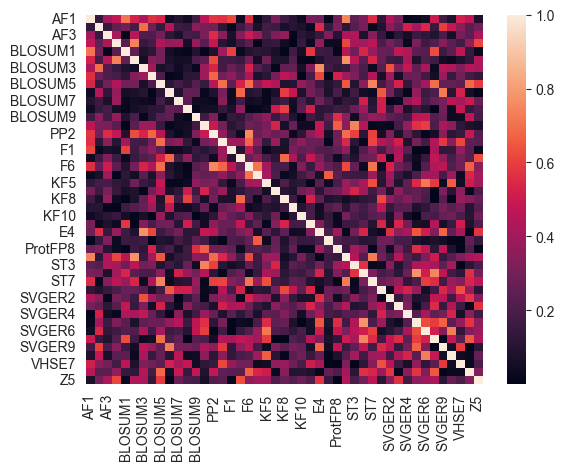

In [7]:
# one more variance matrix
corr_matrix = df_feat.corr().abs()
sns.heatmap(corr_matrix, annot=False)

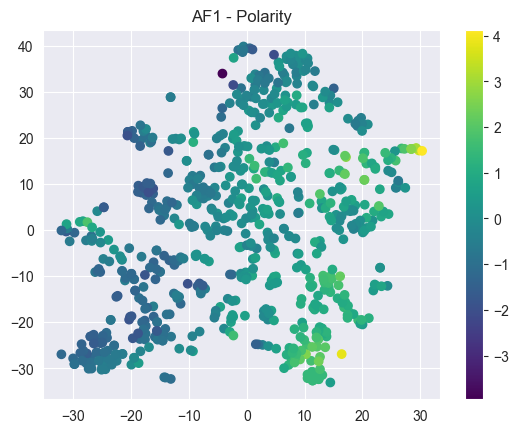

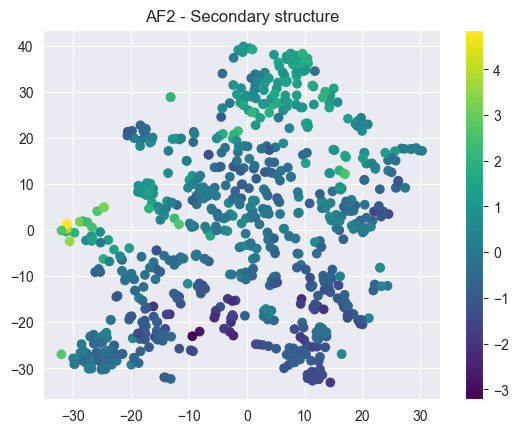

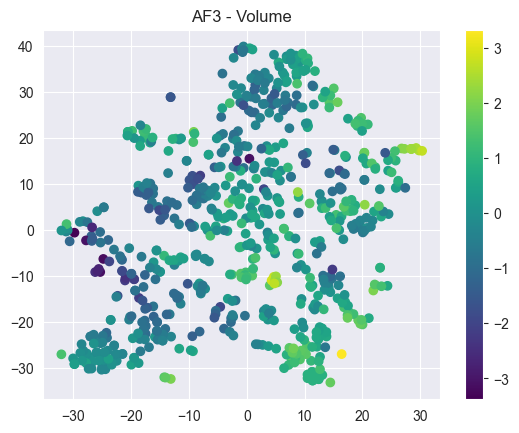

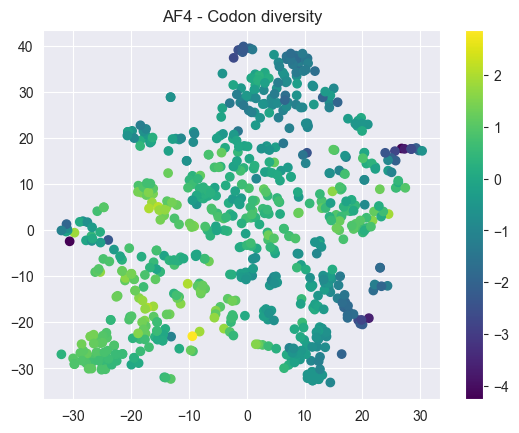

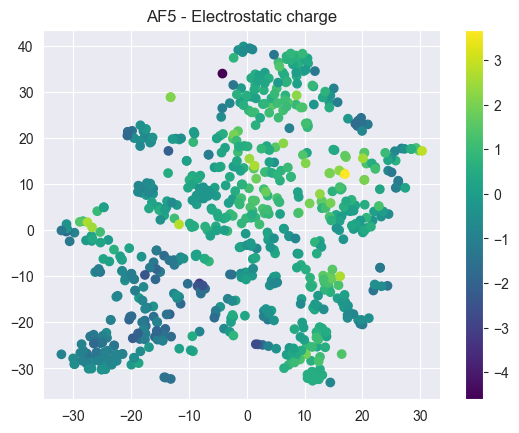

In [8]:
# TSNE for Atchley factors
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(df_feat)

# gradient for the atchley features
names = ["AF1 - Polarity", "AF2 - Secondary structure", "AF3 - Volume", "AF4 - Codon diversity", "AF5 - Electrostatic charge"]
for i in range(len(names)):
    plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=df_feat.iloc[:, i], cmap='viridis')
    plt.colorbar()
    plt.title(names[i])
    plt.savefig("atchley_" + names[i] + ".png")
    plt.show()

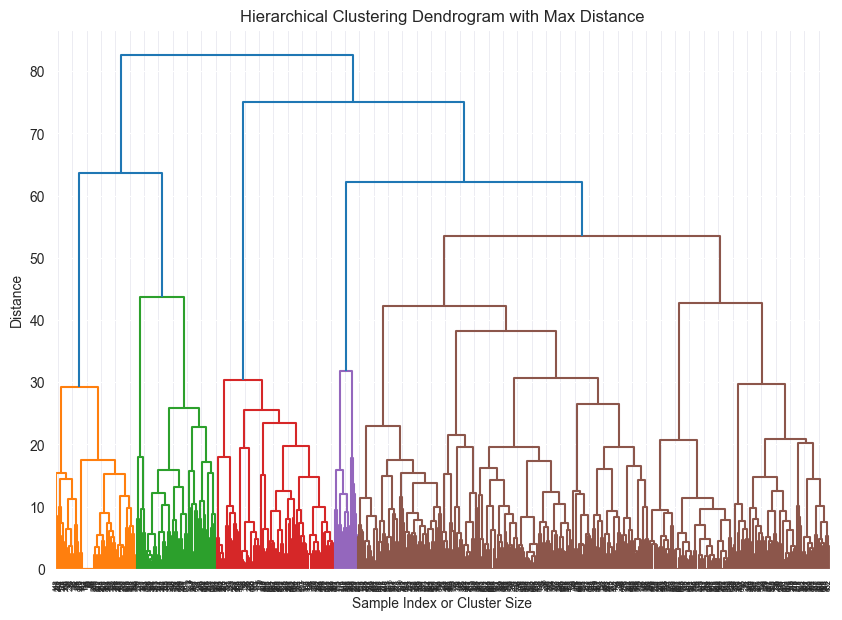

In [9]:
# dendrogram visualization
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.title('Hierarchical Clustering Dendrogram with Max Distance')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')

linked = shc.linkage(df_feat, method='ward')
# max_distance = linked[:, 2].max() 
# plt.text(len(df_feat) / 2, max_distance, f'Max Distance: {max_distance:.2f}', ha='center', va='bottom', color='red')

dend = shc.dendrogram(linked)
# plt.axhline(y=max_distance, c='red', linestyle='--', label=f'Max Distance: {max_distance:.2f}')
# print(f"Max distance: {max_distance:.2f}")
plt.savefig("dendrogram.png")
plt.show()

In [10]:
# KMeans clustering

from sklearn import metrics
from sklearn.cluster import KMeans

silhouette_scores = []
number_of_clusters = []
for i in range(2, 500):
    kmeans = KMeans(n_clusters=i, random_state=0).fit(df_feat)
    score = metrics.silhouette_score(df_feat, kmeans.labels_, metric='euclidean')
    silhouette_scores.append(score)
    print(score)
    number_of_clusters.append(i)

dict_scores = sorted(zip(number_of_clusters, silhouette_scores), key=lambda x: x[1], reverse=True)
print("The top 3 silhouette scores are:\n")
for i in range(3):
    print(f"Number of clusters: {dict_scores[i][0]}, Silhouette score: {dict_scores[i][1]:.2f}")
avg = sum(silhouette_scores) / len(silhouette_scores)
print("Mean silhouette score:" + str(avg))

0.16093720955481844
0.13818002455914777
0.12068656104473895
0.14550059694262593
0.13996878576211894
0.15335678070098852
0.14953566220706074
0.1548820659708585
0.15853721367752316
0.14215083075051374
0.14643570214123977
0.13834910395725486
0.14550931999959668
0.14722128276744212
0.14081161912102685
0.1371930345648383
0.1531826155786036
0.141408862402681
0.13812099852121423
0.14923514643671928
0.1548008267042847
0.16424968232806197
0.16698972678059287
0.1647117483477299
0.17059520721303367
0.17499044240896047
0.1774594568589594
0.1751469238127179
0.17284193622868416
0.17441297915689266
0.17225188682665873
0.17164303446003112
0.17293867900496046
0.17344285665073653
0.17642475974815583
0.1769752410717463
0.18089380936746577
0.17334289212960416
0.17141036799189371
0.17264871855238992
0.17693134456855283
0.1747713509600053
0.17121084732457406
0.17786988478678623
0.1791475289202515
0.1824310022337008
0.18325044096248408
0.18481165333241742
0.18551710059371262
0.18730394406946105
0.18707951687

KMeans(n_clusters=2, random_state=0)


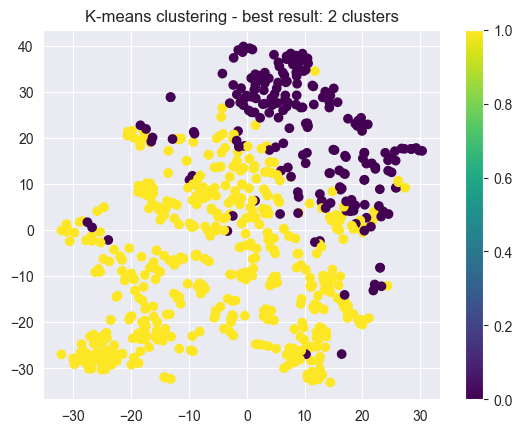

In [11]:
# KMeans clustering for 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0).fit(df_feat)
print(kmeans)

# show plot
import matplotlib.pyplot as plt
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=kmeans.labels_, cmap='viridis')
plt.colorbar()
plt.title("K-means clustering - best result: 2 clusters")
plt.savefig("KMeans_2_clusters.png")

In [12]:
# Agglomerative clustering

from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering

silhouette_scores = []
for i in range(2, 500):
    agg = AgglomerativeClustering(n_clusters=i).fit(df_feat)
    score = metrics.silhouette_score(df_feat, agg.labels_, metric='euclidean')
    silhouette_scores.append(score)
    number_of_clusters.append(i)

dict_scores = sorted(zip(number_of_clusters, silhouette_scores), key=lambda x: x[1], reverse=True)
print("The top 3 silhouette scores are:\n")
for i in range(3):
    print(f"Number of clusters: {dict_scores[i][0]}, Silhouette score: {dict_scores[i][1]:.2f}")
    
avg = sum(silhouette_scores) / len(silhouette_scores)
print("Mean silhouette score:" + str(avg))

The top 3 silhouette scores are:

Number of clusters: 327, Silhouette score: 0.27
Number of clusters: 202, Silhouette score: 0.26
Number of clusters: 324, Silhouette score: 0.26
Mean silhouette score:0.23641291821029584


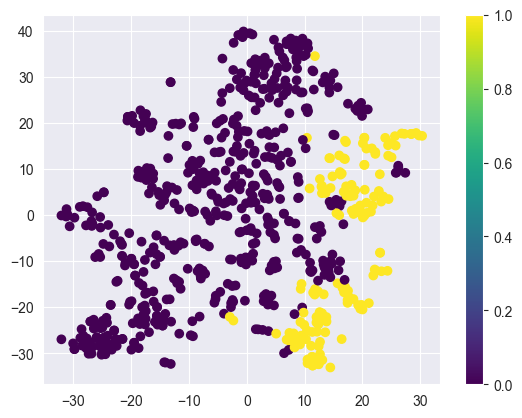

In [13]:
# Agglomerative clustering with 2 clusters
agg = AgglomerativeClustering(n_clusters=2).fit(df_feat)

# show plot
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=agg.labels_, cmap='viridis')
plt.colorbar()

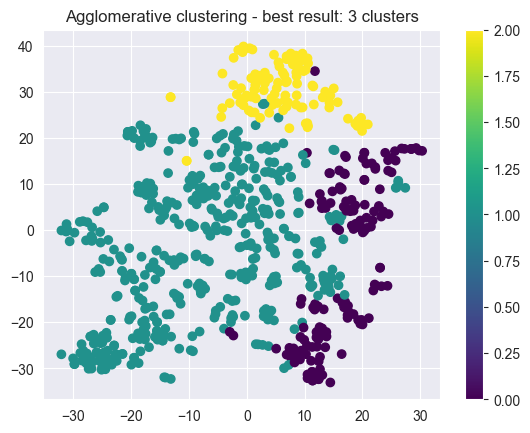

In [14]:
# Agglomerative clustering with 3 clusters
agg = AgglomerativeClustering(n_clusters=3).fit(df_feat)

# show plot
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=agg.labels_, cmap='viridis')
plt.colorbar()
plt.title("Agglomerative clustering - best result: 3 clusters")
plt.savefig("Agglomerative_3_clusters.png")

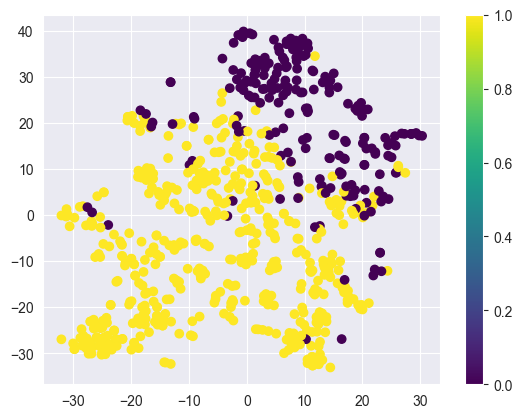

In [15]:
# TSNE, KMeans
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(df_feat)

kmeans = KMeans(n_clusters=2, random_state=0).fit(df_feat)

plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=kmeans.labels_, cmap='viridis')
plt.colorbar()